# Seminário Modelagem Econômica Baseada em Agentes - SCX5013

## 1. Visão geral e motivação do modelo

### 1.1 Trabalhos abordados

Iremos abordar o modelo proposto nos trabalhos:

- `Economic forecasting with an agent-based model`, Poledna et al. (2023)
-  `Behavioural agent-based economic forecasting in Julia`, implementação open source na linguagem Julia por Aldo et al. (2025)

Utilizaremos a implementação em Julia para explorar o modelo de maneira prática. 

### 1.2 Motivadores do modelo

As principais motivações do trabalho são:
- Realizar `previsões macroeconômicas` utilizando modelagem baseada em agentes.

- Construir uma modelagem verossimilhante, calibrando o modelo de acordo com as estatísticas governamentais e executando a simulação com escala 1:1 da população do país.

O modelo inicial foi calibrado para a economia da Áustria, que é um país pequeno e altamente integrado com a economia externa ($ \approx 9M$ habitantes  e $\approx 50\%  $ do PIB em importações/exportações). 

O trabalho se encaixa nas características centrais dos modelos macroeconômicos baseados em agentes definidos em Delli Gatti (2018):

> "Em modelos macroeconômicos baseados em agentes, tipos diferentes de agentes heterogêneos com regras comportamentais e de expectativas interagem através de protocolos de mercado explícitos e variáveis meso e macroeconômicas são determinadas através da agregação dos resultados dessa população de agentes." (tradução livre) 

> "In agent-based macroeconomic models, different types of heterogeneous agents endowed with behavioral and expectational rules interact through explicitly represented market protocols and meso as well as macroeconomic variables are determined by actual aggregation of the output in this population of agents."

### 1.3 Inicialização do modelo

Com os comandos abaixo inicializamos as condições de partida do modelo: 
- Parâmetros (fixos).

- Variáveis de estado (evoluem no tempo).

In [71]:
import BeforeIT as Bit
import Random
using Plots, StatsPlots, DataFrames, Statistics, LinearAlgebra


parameters = Bit.AUSTRIA2010Q1.parameters;
initial_conditions = Bit.AUSTRIA2010Q1.initial_conditions;
model = Bit.Model(parameters,initial_conditions);

### 1.4 Agentes do modelo

Podemos inspecionar as condições iniciais para nos informarmos sobre os agentes do modelo.

In [28]:
p = model.prop

agent_table = DataFrame(
        "Agent type"        => ["Trabalhadores ativos (empregados e desempregados)",
                                "Trabalhadores inativos",
                                "Empresas (e donos de empresas)",
                                "Governos (central e locais)",
                                "Consumidores externos",
                                "Empresas estrangeiras (importadoras)",
                                "Banco central (Taxa Básica)",
                                "Banco comercial representativo (Taxa de Juros)"],
        "Count"             => [p.H_act, p.H_inact, p.I, p.J, p.L, p.G, round(100*model.cb.r_bar; digits = 2), round(100*model.bank.r;digits =2)],
    )

Row,Agent type,Count
,String,Float64
1,Trabalhadores ativos (empregados e desempregados),4743.0
2,Trabalhadores inativos,4130.0
3,Empresas (e donos de empresas),624.0
4,Governos (central e locais),156.0
5,Consumidores externos,312.0
6,Empresas estrangeiras (importadoras),62.0
7,Banco central (Taxa Básica),0.16
8,Banco comercial representativo (Taxa de Juros),2.84


### 1.5 Evolução temporal 

Cada etapa temporal do modelo equivale a um `trimestre`. As etapas-chave que levam o modelo de $t$ para $t+1$ são:

1. Formação de expectativas coletivas - regra AR(1) 

2. Execução dos choques exógenos - regra AR(1)

3. Execução dos mercados de crédito e trabalho

4. Execução dos mercados de bens  

4. Atualização da contabilidade

Abaixo, veremos a progressão de algumas dessas variáveis a partir de uma execução prática do modelo. 

In [29]:
T_horizon = 20 # 20 trimestres / 5 anos
Random.seed!(123)
Bit.run!(model, T_horizon);

BeforeIT.Model{BeforeIT.Workers, BeforeIT.Workers, BeforeIT.Firms, BeforeIT.Bank, BeforeIT.CentralBank, BeforeIT.Government, BeforeIT.RestOfTheWorld, BeforeIT.Aggregates, BeforeIT.Properties, BeforeIT.Data}(BeforeIT.Workers(Base.RefValue{Bool}(false), Base.RefValue{Int64}(4118), Dict{Int64, Int64}(), [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  4109, 4110, 4111, 4112, 4113, 4114, 4115, 4116, 4117, 4118], [0.8718231478778272, 0.8521693252073859, 0.8718231478778272, 0.8679534910752549, 0.858397699166757, 0.8525769662515496, 0.8721366114848635, 0.8690600519970554, 0.8720611479225368, 0.8718231478778272  …  4.718390557572999, 3.39015200375075, 4.544094196258163, 4.4740386479640835, 4.760456141088883, 4.731613067422093, 5.202953916282366, 3.434904239855824, 4.54154703304583, 5.731345325269658], [4.3900204064876975, 4.298193564102061, 4.404112061419337, 4.335537616527198, 4.299752785224663, 4.315816681091994, 4.2856784100940315, 4.292086935032863, 4.340761231177201, 4.316455488029438  …  26.2506534940

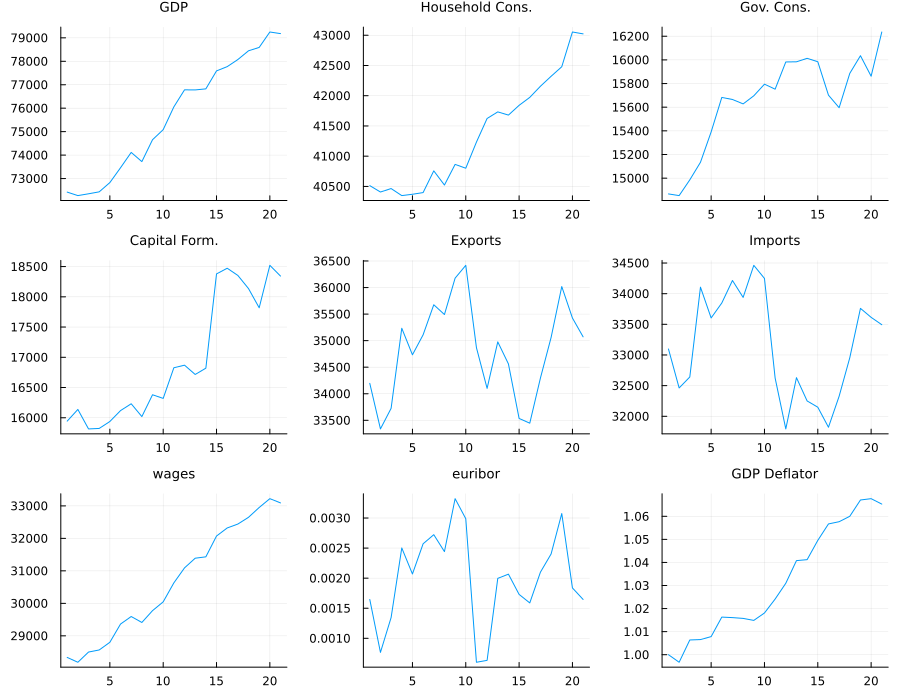

In [30]:
ps = Bit.plot_data(
        begin model end,
        quantities = [
            :real_gdp,
            :real_household_consumption,
            :real_government_consumption,
            :real_capitalformation,
            :real_exports,
            :real_imports,
            :wages,
            :euribor,
            :gdp_deflator,
        ],
    )
    plot(ps..., layout = (3, 3), size = (900, 700))

Cada passo equivale a 47 funções executadas sequencialmente. Verificamos então como as estatísticas agregadas da economia evoluem ao longo do tempo:
- Crescimento da economia

- Inflação

- Desemprego

Observamos também que o modelo possui propriedades emergentes que também são verificadas na economia, como:
- Oscilações econômicas

- Tendência de crescimento sustentada do PIB (países industrializados)


## 2. Regras autoregressivas de ordem 1 - AR(1)

### 2.1 O que são as relações AR(1)

As regras autoregressivas de ordem 1 são o cálculo de uma variável no futuro, $z_{t+1}$, a partir de uma relação linear desta variável no passo de tempo anterior, ou seja:

$$z_{t+1} = \alpha z_{t} + \beta$$

Em Poledna et al., essa regra é utilizada para:
- Formação das expectativas coletivas de crescimento do PIB e inflação.

- Modelagem de eventos exógenos com choques aleatórios (importações, exportações, gasto do governo, inflação e crescimento da área do euro).


### 2.2 Uso nas expectativas

Com relação às expectativas de PIB e inflação:
- A cada semestre os agentes calculam os parâmetros de maneira otimizada (com o melhor fit possível com relação aos dados históricos).

- Na prática, os agentes estão aprendendo e atualizando suas expectativas, o que os torna `adaptativos`.

Por exemplo, para as empresas a produção desejada no próximo período é:

$$
Q_i^s=Q_i^d(1+\gamma^e)
$$

$$
\begin{aligned}
i &: \text{empresa considerada}\\
Q_i^s &: \text{produção desejada pela empresa }i\\
Q_i^d &: \text{demanda pelo produto da empresa }i\text{ no período anterior}\\
\gamma^e &: \text{taxa esperada de crescimento da economia}
\end{aligned}
$$


Para os consumidores o consumo desejado no próximo período é: 

$$
Y_h^e=
\left[w_h(1-\tau_{\mathrm{SIW}})(1-\tau_{\mathrm{INC}})+sb^{\mathrm{other}}\right]
\bar P_{HH}(1+\pi^e)
$$

$$
\begin{aligned}
Y_h^e &: \text{renda disponível esperada do trabalhador }h\\
w_h &: \text{salário antes dos descontos}\\
\tau_{\mathrm{SIW}} &: \text{contribuição social do trabalhador}\\
\tau_{\mathrm{INC}} &: \text{imposto de renda}\\
sb^{\mathrm{other}} &: \text{outros benefícios sociais}\\
\bar P_{HH} &: \text{índice de preços do consumo das famílias}\\
\pi^e &: \text{inflação esperada}
\end{aligned}
$$

Abaixo vamos ilustrar como as regras AR(1) são calculadas na prática.

[ Info: Saved animation to /Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/seminario-economia/ar1.gif
[ Info: Saved animation to /Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/seminario-economia/ar1.gif


Plots.AnimatedGif("/Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/seminario-economia/ar1.gif")
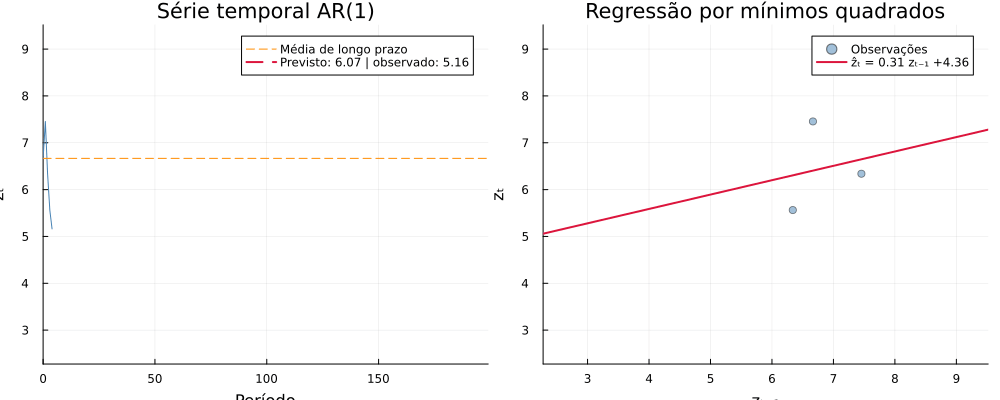

In [40]:
using Random, Plots, Printf

Random.seed!(42)
alpha_true = 0.7
beta_true = 2.0
n_observations = 200
long_run_mean = beta_true / (1 - alpha_true)

z = fill(long_run_mean, n_observations)
for t in 2:n_observations
    z[t] = alpha_true * z[t-1] + beta_true + randn()
end

xs = range(minimum(z), maximum(z); length = 100)

previsoes = fill(NaN, n_observations)

anim = @animate for k in 5:n_observations
    # Ajusta a regra usando apenas os períodos anteriores
    lagged, current = z[1:k-2], z[2:k-1]
    alpha, beta = hcat(lagged, ones(length(lagged))) \ current
    previsoes[k] = alpha * z[k-1] + beta

    p1 = plot(0:k-1, z[1:k];
        xlims = (0, n_observations-1), ylims = extrema(z),
        color = :steelblue, title = "Série temporal AR(1)",
        xlabel = "Período", ylabel = "zₜ", label = false)
    hline!(p1, [long_run_mean];
        color = :darkorange, linestyle = :dash,
        label = "Média de longo prazo")
    plot!(p1, 4:k-1, previsoes[5:k];
        color = :crimson, linestyle = :dash, linewidth = 2,
        label = @sprintf("Previsto: %.2f | observado: %.2f", previsoes[k], z[k]))

    p2 = scatter(lagged, current;
        xlims = extrema(z), ylims = extrema(z),
        alpha = 0.5, color = :steelblue, label = "Observações",
        title = "Regressão por mínimos quadrados",
        xlabel = "zₜ₋₁", ylabel = "zₜ")
    plot!(p2, xs, alpha .* xs .+ beta;
        color = :crimson, linewidth = 2,
        label = @sprintf("ẑₜ = %.2f zₜ₋₁ %+.2f", alpha, beta))

    plot(p1, p2; layout = (1, 2), size = (1000, 400))
end

gif(anim, "ar1.gif"; fps = 4)

gif(anim, "ar1.gif"; fps = 4)

Os argumentos principais para o uso dessa regra são:
- É uma regra simples mas poderosa, onde os agentes ignoram as não linearidades que estão por trás das variáveis econômicas mas conseguem construir uma previsão da direção da econômia que instrumenta suas decisões. 

- Os autores indicam que regras como esta já foram verificadas experimentalmente para comportamento humano com relação à previsão de variáveis econômicas.    

- Os dados utilizados para o cálculo das regressões são os dados reais da economia austríaca o que reforça a verossimilhança do modelo. 

Por fim, outra implicação é que como estas expectativas são compartilhadas e o $\alpha$ verificado é próximo de 1 o sistema tende a operar ao redor de um ponto de equilíbrio, que os autores denominam de `"Behavioural Learning Equilibrium"`. 

#### Verificação Matemática

$$z_{t+1} = \alpha z_{t} + \beta$$

Se: $$ \alpha \approx 1 \implies z_{t+1} = z_{t} + \beta $$

Resolvendo a recorrência:

$$ z_{1} = z_{0} + \beta ,    $$

$$z_{2} = z_{1} + \beta =  (z_{0} + \beta ) + \beta \implies z_{2} = z_{0} + 2 \beta  $$

Repetindo esse procedimento, temos:

$$ z_t = z_0 + t \beta $$

## 3. Calibração para as contas nacionais 

### 3.1 Estratégia de calibração 

O trabalho busca se adequar às estatísticas de contabilidade nacional. 

Nesse sentido, os parâmetros do modelo são:
- Retirados diretamente das estatísticas oficiais.

- Ou calculados a partir delas.

Isto torna o modelo mais verossimilhante e reduz a necessidade de estimação de parâmetros livres, uma das grandes críticas aos ABMs. 

Abaixo iremos explorar alguns dos parâmetros/estatísticas mais interessantes do modelo.

In [ ]:
tabela = DataFrame(
    Parametro = ["H_act", "tau_INC", "psi", "theta_UB"],
    Valor = [
        string(Int(round(parameters["H_act"]))),
        string(round(100 * parameters["tau_INC"]; digits=2), "%"),
        string(round(100 * parameters["psi"]; digits=2), "%"),
        string(round(100 * parameters["theta_UB"]; digits=2), "%"),
    ],
    Significado = [
        "Agentes economicamente ativos",
        "Alíquota média de imposto de renda das famílias",
        "Parcela da renda disponível destinada ao consumo",
        "Reposição do benefício de desemprego sobre o salário bruto",
    ],
    Calculo = [
        "empregados + desempregados + proprietários de firmas + 1",
        "(IR familiar + impostos de capital) / (salários + renda de propriedade + renda mista - contribuições sociais)",
        "(consumo das famílias + impostos sobre consumo) / renda disponível",
        "0,55 × (1 - tau_INC) × (1 - tau_SIW)",
    ],
    Fonte = [
        "Censo e demografia empresarial",
        "Estatísticas do governo e contas setoriais",
        "Tabelas de insumo-produto e contas setoriais",
        "Regra austríaca: 55% da renda líquida",
    ],
)

tabela


Row,Parametro,Valor,Significado,Calculo,Fonte
,String,String,String,String,String
1,H_act,4743,Agentes economicamente ativos,empregados + desempregados + proprietários de firmas + 1,Censo e demografia empresarial
2,tau_INC,21.34%,Alíquota média de imposto de renda das famílias,(IR familiar + impostos de capital) / (salários + renda de propriedade + renda mista - contribuições sociais),Estatísticas do governo e contas setoriais
3,psi,90.97%,Parcela da renda disponível destinada ao consumo,(consumo das famílias + impostos sobre consumo) / renda disponível,Tabelas de insumo-produto e contas setoriais
4,theta_UB,35.86%,Reposição do benefício de desemprego sobre o salário bruto,"0,55 × (1 - tau_INC) × (1 - tau_SIW)",Regra austríaca: 55% da renda líquida


### 3.2 Matriz insumo-produto

A matriz insumo-produto, concebida inicialmente por Leontief, descreve as relações entre os diferentes setores produtivos:

- Cada linha representa um setor fornecedor $s$ e cada coluna um setor produtor $g$. 
- A entrada $a_{sg}$ é a participação do setor $s$ nos insumos intermediários usados pelo setor $g$. Cada coluna soma 1.  

Como exemplo, abaixo temos uma demonstração dos insumos do setor de educação. 

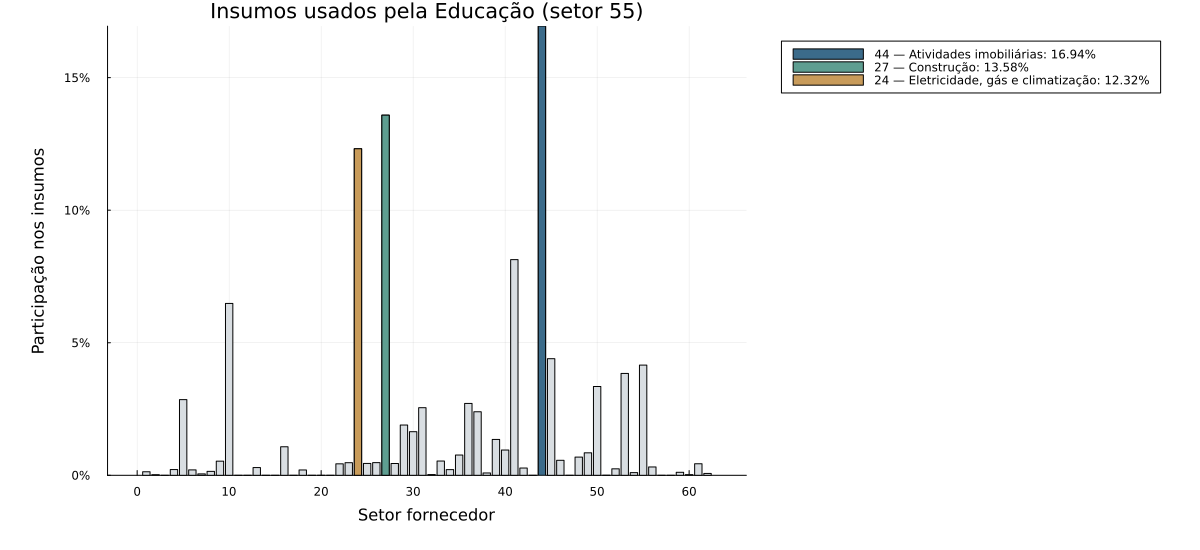

In [78]:
io_weights = model.prop.a_sg
pesos = model.prop.a_sg[:, 55]
maiores = sortperm(pesos; rev=true)[1:3]

nomes = Dict(
    44 => "Atividades imobiliárias",
    27 => "Construção",
    24 => "Eletricidade, gás e climatização",
)
cores = ["#3B6B8A", "#5E9E91", "#C89B5A"]  # azul, verde e dourado

p = bar(1:length(pesos), pesos;
    color="#D9DEE2", label=false, bar_width=0.8,
    title="Insumos usados pela Educação (setor 55)",
    xlabel="Setor fornecedor", ylabel="Participação nos insumos",
    yformatter=y -> "$(round(Int, 100y))%",
    legend=:outertopright, size=(1100, 460)
)

for (posição, setor) in enumerate(maiores)
    nome = get(nomes, setor, "Setor $setor")
    bar!(p, [setor], [pesos[setor]];
        color=cores[posição], bar_width=0.8,
        label="$setor — $nome: $(round(100pesos[setor]; digits=2))%"
    )
end

plot!(p;
    size=(1200, 550),
    left_margin=12Plots.mm,
    bottom_margin=10Plots.mm,
    right_margin=8Plots.mm
)

p

Abaixo, um mapa de calor da matriz de insumo-produto. Os pontos mais brilhantes são aqueles que representam maior relação entre setor e produto. 

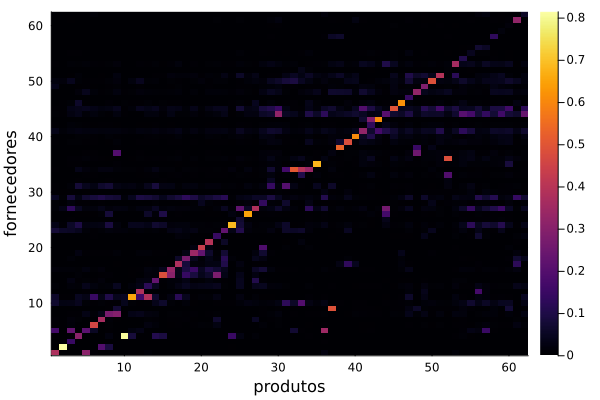

In [66]:
heatmap(io_weights, xlabel = "produtos", ylabel = "fornecedores",)

#### Histórico da matriz

Em um texto de 1951 sobre a matriz insumo-produto, Leontief diz: 

>O efeito de um acontecimento num ponto em particular é transmitido ao resto da economia, passo a passo, mediante uma série de transações que vinculam a totalidade do sistema num só conjunto. Uma tabela de razões para o conjunto da economia nos dá, com tanto detalhe quanto quisermos, um quadro quantitativamente determinado da estrutura interna do sistema. Isso possibilita o cálculo detalhado das conseqüências decorrentes da introdução no sistema de variações sugeridas pelo problema teórico ou prático que enfrentamos.

Nesse sentido, o modelo vai ao encontro da visão original da matriz ao propor a simulação dos acontecimentos econômicos a partir de relações construídas empiricamente. 

Além disso, ao falar do problema de inversão da matriz (saber os insumos necessários a partir do resultado desejado) , ele coloca: 

>Uma típica solução geral de uma tabela de 42 setores para 1939 demorou 56 horas no computador Mark II de Harvard.

Hoje, isso pode ser feito em segundos. Para obter os coeficientes por unidade produzida, dividimos cada coluna de $a_{sg}$ por $\beta_g$, a razão entre produção e consumo intermediário do setor $g$. A inversa de Leontief é então $(I-A)^{-1}$, com $A_{sg}=a_{sg}/\beta_g$.

In [79]:
beta_s = vec(parameters["beta_s"])
A = model.prop.a_sg ./ beta_s'  # insumo do setor s por unidade produzida no setor g
inversa_leontief = inv(I - A)

demanda_final = zeros(size(A, 1))
demanda_final[55] = 1  # uma unidade adicional de demanda por educação
producao_total = inversa_leontief * demanda_final

setores = sortperm(producao_total; rev=true)[1:10]
DataFrame(setor=setores, producao_necessaria=producao_total[setores])

Row,setor,producao_necessaria
,Int64,Float64
1,55,1.00581
2,24,0.0414947
3,27,0.0302856
4,44,0.0286633
5,4,0.0178657
6,41,0.0175113
7,45,0.0150364
8,10,0.0114625
9,53,0.00859417


### 3.3 Consistência fluxo-estoque

Outro ponto importante é a consistência estoque-fluxo do modelo:

- Não há um recurso estranho entrando no modelo ("na mão").

- Cada transação, compra ou venda, tem um lastro no balanço dos agentes do modelo.

Na prática isso quer dizer que as identidades macroeconômicas são respeitadas, tudo que é produzido é consumido ou poupado. 

Ou seja:

$$ Y = C + G + I + E - I $$


Assim, o produto é igual à soma do consumo das famílias, do governo, ao investimento, às exportações menos as importações. E isto vale a todo instante do modelo. 

In [82]:
C = model.data.real_household_consumption
I_inv = model.data.real_capitalformation
G = model.data.real_government_consumption
X = model.data.real_exports
M = model.data.real_imports
Y_prod = model.data.real_gdp        # production-side GDP

Y_exp  = C .+ I_inv .+ G .+ X .- M  # expenditure-side GDP

residual = Y_exp .- Y_prod
max_err  = maximum(abs.(residual))
rel_err  = max_err / mean(Y_prod) * 100

DataFrame(
    "Stat"  => ["Max |residual| (€ real)", "Max relative error (%)"],
    "Value" => [round(max_err, sigdigits=4), round(rel_err, sigdigits=4)],
)

Row,Stat,Value
,String,Float64
1,Max |residual| (€ real),2.91e-11
2,Max relative error (%),4.019e-14


### 3.4 Conexão calibração e previsão

Por fim, como o objetivo do modelo é produzir previsões macroeconômicas, esta calibração é essencial para que numericamente as previsões façam sentido. 

## 4. Mercados com fricção  ("Search and Matching")

Outra característica relevante do modelo é como os agentes econômicos, empresas, famílias e governos, se relacionam em mercados para produzir e consumir. 
 
Isto se dá através de mercados: 
- Descentralizados: os consumidores são ordenados em ordem aleatória.

- Probabilísticos: empresas são escolhidas com probabilidade proporcional ao seu tamanho e preço praticado. 

De acordo com os autores:
- Este método permite reproduzir fricções nas relações de troca e, portanto, mercados que não estão necessariamente em equilíbrio. 

- Assim, é possível que consumidores não consigam comprar tudo que tinham em seu orçamento e é possível que empresas não consigam vender tudo aquilo que produziram. 

- No entanto, caso não haja mudanças abruptas no sistema, as empresas e consumidores tendem a caminhar em um percurso próximo ao equilíbrio onde a oferta se iguala à demanda.      

[ Info: Saved animation to /Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/seminario-economia/matching-100x20.gif


Plots.AnimatedGif("/Users/danielbandrade/Documents/programing/BeforeIT-dba/dba-studies/seminario-economia/matching-100x20.gif")
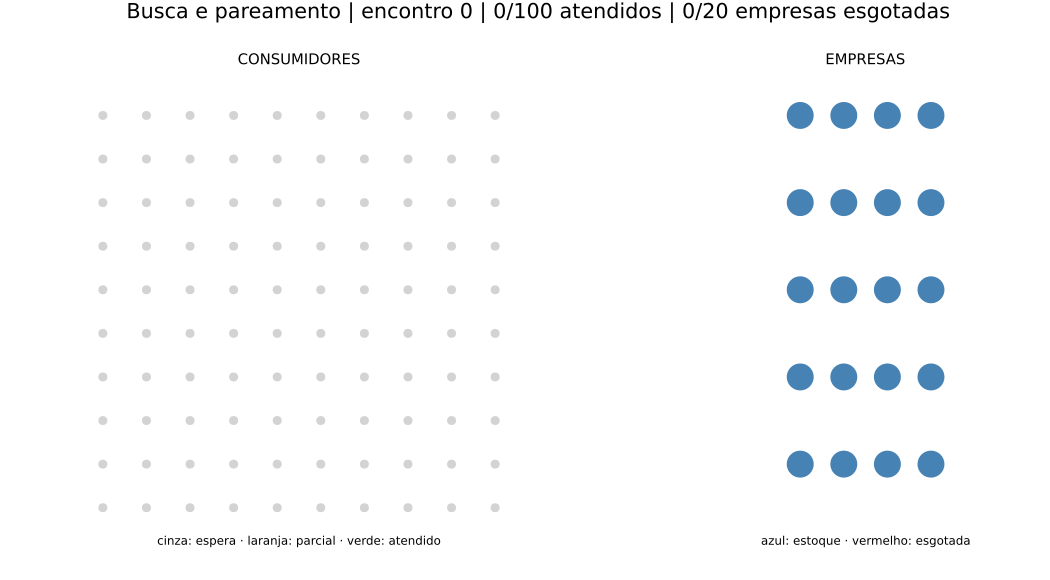

In [68]:
using Random, Plots, StatsBase

function animar_matching(; arquivo="matching-100x20.gif")
    rng = MersenneTwister(42)
    nc, nf = 100, 20

    orcamento = Float64[9 + mod(37i, 17) for i in 1:nc]
    comprado = zeros(nc)
    preco = [1 + mod(7j, 12) / 10 for j in 1:nf]
    estoque_inicial = Float64[45 + mod(13j, 26) for j in 1:nf]
    estoque = copy(estoque_inicial)

    # Peso de escolha: preferência por preço + participação na oferta inicial.
    p_preco = exp.(-2 .* preco)
    pesos = p_preco ./ sum(p_preco) .+ estoque_inicial ./ sum(estoque_inicial)

    xc = [1 + mod(i - 1, 10) for i in 1:nc]
    yc = [10 - div(i - 1, 10) for i in 1:nc]
    xf = [17 + mod(j - 1, 4) for j in 1:nf]
    yf = [10 - 2 * div(j - 1, 4) for j in 1:nf]

    function quadro(i, j, quantidade, encontro)
        atendidos = count(x -> x <= 1e-9, orcamento)
        esgotadas = count(x -> x <= 1e-9, estoque)

        p = plot(;
            xlims=(0, 22), ylims=(0, 12), size=(1050, 580),
            axis=false, grid=false, aspect_ratio=:equal, legend=false,
            background_color=:white,
            title="Busca e pareamento | encontro $encontro | $atendidos/$nc atendidos | $esgotadas/$nf empresas esgotadas"
        )

        if i > 0
            plot!(p, [xc[i], xf[j]], [yc[i], yf[j]];
                color=:darkorange, linewidth=2, alpha=0.8, label=false)
        end

        grupos = (
            (findall(k -> comprado[k] == 0, 1:nc), :lightgray),
            (findall(k -> comprado[k] > 0 && orcamento[k] > 1e-9, 1:nc), :orange),
            (findall(k -> orcamento[k] <= 1e-9, 1:nc), :seagreen3)
        )
        for (ids, cor) in grupos
            scatter!(p, xc[ids], yc[ids];
                markersize=5, markerstrokewidth=0, color=cor, label=false)
        end

        ativas = findall(x -> x > 1e-9, estoque)
        vazias = findall(x -> x <= 1e-9, estoque)
        scatter!(p, xf[ativas], yf[ativas];
            markersize=6 .+ 9 .* estoque[ativas] ./ estoque_inicial[ativas],
            color=:steelblue, markerstrokewidth=0, label=false)
        scatter!(p, xf[vazias], yf[vazias];
            markersize=6, color=:firebrick, markerstrokewidth=0, label=false)

        annotate!(p, 5.5, 11.3, text("CONSUMIDORES", 10, :black))
        annotate!(p, 18.5, 11.3, text("EMPRESAS", 10, :black))
        annotate!(p, 5.5, 0.25,
            text("cinza: espera · laranja: parcial · verde: atendido", 8, :black))
        annotate!(p, 18.5, 0.25,
            text("azul: estoque · vermelho: esgotada", 8, :black))

        if i > 0
            annotate!(p, 11, 11.3,
                text("Consumidor $i → empresa $j: $(round(quantidade; digits=1)) unidades",
                    10, :black))
        end
        p
    end

    anim = Animation()
    frame(anim, quadro(0, 0, 0, 0))

    fila = Int[]
    encontros = 0
    while any(x -> x > 1e-9, orcamento) && any(x -> x > 1e-9, estoque)
        isempty(fila) &&
            (fila = shuffle(rng, findall(x -> x > 1e-9, orcamento)))

        i = pop!(fila)
        ativas = findall(x -> x > 1e-9, estoque)
        j = sample(rng, ativas, Weights(pesos[ativas]))

        quantidade = min(estoque[j], orcamento[i] / preco[j])
        estoque[j] = max(0, estoque[j] - quantidade)
        orcamento[i] = max(0, orcamento[i] - quantidade * preco[j])
        comprado[i] += quantidade

        encontros += 1
        frame(anim, quadro(i, j, quantidade, encontros))
    end

    gif(anim, arquivo; fps=6)
end

animar_matching()

## 5. Ciclo completo

Retomando, o ciclo completo do modelo se caracteriza por:

![alt text](fluxo-completo-mermaid-diagram.png)

## 6. Resultados

### 6.1 Metodologia para mensuração de performance

As previsões foram calculadas para dados fora da amostra de calibração e o erro do modelo foi comparado com os modelos abaixo.

Hipóteses nulas:
- AR (1): a própria regra autoregressiva que os agentes utilizam.

- VAR (1): uma extensão com lags adicionais ($z_{t-1},z_{t-2}...$) do modelo AR (1).

Benchmarks:
- VECM (Vector Error Correction Model): O VECM  é um modelo estatístico de séries temporais usado para analisar variáveis que possuem uma relação de equilíbrio de longo prazo, mesmo que sofram desvios temporários no curto prazo. 

- DSGE (Dynamic Stochastic General Equilibrium): Modelo DSGE  Neo Keyneisiano padrão.

Foram feitas 500 simulações de Monte Carlo para o modelo e realizadas comparações com os dados realizados utilizando RMSE (root mean squared error) para as seguintes variáveis:
- PIB

- Inflação

- Consumo das famílias

- Investimento

- Euribor ("Taxa selic da Europa")

### 6.2 Discussão dos resultados

De maneira geral, o ABM `não apresentou melhoria significativa` em relação aos benchmarks. Apesar disso, para algumas variáveis houve uma melhoria expressiva mas sem significância. 

Mesmo não havendo uma melhoria relevante, é interessante notar que, tendo em vista o que foi apresentado sobre verossimilhança e escala do modelo, o ABM permite realizar uma quantidade bem maior de previsões e, portanto, pode ser considerado mais rico (vide meso-level discutido por Brian Arthur).

Abaixo temos uma das tabelas de resultados do trabalho. 

![alt text](<Screenshot 2026-10-02 at 17.46.06.png>)

## 7. Observações críticas  

De maneira geral, o modelo é bem construído e parcialmente bem-sucedido ao realizar previsões similares aos modelos padrões da economia mainstream (DSGE). 

Constitui uma tentativa inicial de mover os ABMs macroeconômicos do território dos `fatos estilizados`, ou seja, da reprodução qualitativa de regularidades empíricas, para o campo `quantitativo`. 

Assim, podemos apontar algumas fragilidades do modelo que podem ser objeto de futuras melhorias:

- Sistema bancário com um banco representativo.

- A grande parte dos parâmetros fixos estão 'atrasados' em relação ao tempo de previsão e não levam em conta alterações estruturais.

- É possível argumentar que o modelo é "autorrealizável" ao colocar nos agentes expectativas que equivalem ao aprendizado de uma série histórica inteira. 

## Anexos

### A1: Observações

- Uma unidade monetária do modelo equivale a um milhão de euros.
- Empresas estrangeiras fazem parte do vetor de produtos no search and matching 

### A2: Resumo ODD

- Revisão ODD

### A3: Varredura complexidade

- Fazer varredura considerando os conceitos de sistemas complexos (camilo)